# Transformer encoder simple en Keras para análisis de sentimiento

## Sesión 6: Transformers / LLMs

En este notebook construiremos una versión simplificada de un **transformer encoder** usando Keras/TensorFlow.

La idea es entender cómo se combinan algunos componentes fundamentales de esta arquitectura:

- embeddings de tokens,
- embeddings de posición,
- self-attention,
- conexiones residuales,
- normalización,
- red feed-forward.

Aplicaremos este modelo a una tarea de **clasificación de sentimiento** usando reseñas del dominio **Amazon Baby Products**.

## Objetivo pedagógico

Al finalizar este notebook deberíamos poder:

- entender la estructura general de un encoder transformer,
- identificar las partes principales del modelo,
- construir un clasificador de texto con Keras/TensorFlow,
- relacionar esta arquitectura con lo visto antes en LSTM y con la idea de self-attention.

Este notebook no usa un modelo preentrenado.
Aquí el objetivo es **entender la construcción del encoder transformer**.

## Hoja de ruta del notebook

Seguiremos estos pasos:

1. cargar y preparar datos,
2. tokenizar y convertir el texto a secuencias,
3. definir embeddings de token y posición,
4. construir un bloque encoder transformer,
5. armar el modelo completo,
6. entrenar y evaluar,
7. comparar conceptualmente con LSTM.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pandas import read_csv

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Función auxiliar para visualizar entrenamiento

Usaremos una función simple para graficar la evolución de accuracy y loss durante el entrenamiento.

In [2]:
def plot_history(history):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(6, 4))
    plt.plot(history_df["accuracy"], label="train_accuracy")
    if "val_accuracy" in history_df.columns:
        plt.plot(history_df["val_accuracy"], label="val_accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title("Accuracy durante el entrenamiento")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history_df["loss"], label="train_loss")
    if "val_loss" in history_df.columns:
        plt.plot(history_df["val_loss"], label="val_loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title("Loss durante el entrenamiento")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Cargamos el dataset

Trabajaremos con reseñas de productos del dominio **Amazon Baby Products**.

La tarea será de **clasificación binaria**:

- una reseña positiva,
- o una reseña negativa.

En este notebook asumimos que ya tenemos un archivo con dos columnas principales:

- `review`
- `label`

Si el nombre de tus columnas en el archivo original es distinto, solo habría que ajustarlo en la celda correspondiente.

In [3]:
## Downloading data
!wget https://github.com/adoc-box/Datasets/blob/6d80f44a12aca282b7f2ff638866edef4806a282/amazon_baby.zip?raw=True

## Rename file
!mv "amazon_baby.zip?raw=True" "amazon_baby.zip"

## Un-compress downloaded zip file
!unzip amazon_baby.zip

--2026-04-27 21:18:01--  https://github.com/adoc-box/Datasets/blob/6d80f44a12aca282b7f2ff638866edef4806a282/amazon_baby.zip?raw=True
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/adoc-box/Datasets/raw/6d80f44a12aca282b7f2ff638866edef4806a282/amazon_baby.zip [following]
--2026-04-27 21:18:01--  https://github.com/adoc-box/Datasets/raw/6d80f44a12aca282b7f2ff638866edef4806a282/amazon_baby.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adoc-box/Datasets/6d80f44a12aca282b7f2ff638866edef4806a282/amazon_baby.zip [following]
--2026-04-27 21:18:02--  https://raw.githubusercontent.com/adoc-box/Datasets/6d80f44a12aca282b7f2ff638866edef4806a282/amazon_baby.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.

In [4]:
df = pd.read_csv('amazon_baby.csv')

df.head()

,name,review,rating
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5


In [5]:
## Lets assing label as: ratings {1,2} to 0, and the rest to 1
df['label'] = df['rating'].apply(lambda x: 0 if x in [1, 2] else 1)

df.head()

,name,review,rating,label
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3,1
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,1
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,1
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,1
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,1


## Revisamos valores faltantes y distribución de clases

In [6]:
df = df[["review", "label"]].dropna().copy()

print("Número de ejemplos:", len(df))
print("\nDistribución de clases:")
print(df["label"].value_counts())

Número de ejemplos: 182702

Distribución de clases:
label
1    156309
0     26393
Name: count, dtype: int64


## Miramos algunos ejemplos del texto

In [7]:
for i in range(3):
    print(f"Ejemplo {i+1}")
    print("Label:", df.iloc[i]["label"])
    print("Review:", df.iloc[i]["review"][:500], "...")
    print("-" * 80)

Ejemplo 1
Label: 1
Review: These flannel wipes are OK, but in my opinion not worth keeping.  I also ordered someImse Vimse Cloth Wipes-Ocean Blue-12 countwhich are larger, had a nicer, softer texture and just seemed higher quality.  I use cloth wipes for hands and faces and have been usingThirsties 6 Pack Fab Wipes, Boyfor about 8 months now and need to replace them because they are starting to get rough and have had stink issues for a while that stripping no longer handles. ...
--------------------------------------------------------------------------------
Ejemplo 2
Label: 1
Review: it came early and was not disappointed. i love planet wise bags and now my wipe holder. it keps my osocozy wipes moist and does not leak. highly recommend it. ...
--------------------------------------------------------------------------------
Ejemplo 3
Label: 1
Review: Very soft and comfortable and warmer than it looks...fit the full size bed perfectly...would recommend to anyone looking for this type of

## Separamos entrenamiento y test

Como en notebooks anteriores, separaremos los datos para poder evaluar generalización.

In [8]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["review"].values,
    df["label"].values,
    test_size=0.2,
    random_state=42,
    stratify=df["label"].values
)

print("Train:", len(X_train_text))
print("Test:", len(X_test_text))

Train: 146161
Test: 36541


## Tokenización y secuencias

El modelo no trabaja directamente con texto crudo.

Primero necesitamos:

1. construir un vocabulario,
2. convertir cada reseña en una secuencia de enteros,
3. hacer padding para que todas las secuencias tengan el mismo largo.

In [9]:
VOCAB_SIZE = 20000
MAX_LEN = 120

tokenizer = keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

In [10]:
## Display word-index in tokenizer
word_index = tokenizer.word_index
word_index

{'<OOV>': 1,
 'the': 2,
 'and': 3,
 'i': 4,
 'it': 5,
 'to': 6,
 'a': 7,
 'is': 8,
 'this': 9,
 'for': 10,
 'my': 11,
 'of': 12,
 'in': 13,
 'that': 14,
 'on': 15,
 'with': 16,
 'but': 17,
 'was': 18,
 'have': 19,
 'we': 20,
 'so': 21,
 'not': 22,
 'you': 23,
 'are': 24,
 'as': 25,
 'one': 26,
 'baby': 27,
 'they': 28,
 'very': 29,
 'when': 30,
 'be': 31,
 'great': 32,
 'would': 33,
 'just': 34,
 'at': 35,
 'up': 36,
 'out': 37,
 'use': 38,
 'like': 39,
 'can': 40,
 "it's": 41,
 'all': 42,
 'these': 43,
 'if': 44,
 'our': 45,
 'he': 46,
 'had': 47,
 'she': 48,
 'them': 49,
 'or': 50,
 'her': 51,
 'has': 52,
 'love': 53,
 'seat': 54,
 'little': 55,
 'easy': 56,
 'get': 57,
 'old': 58,
 'from': 59,
 'only': 60,
 'well': 61,
 'will': 62,
 'because': 63,
 'more': 64,
 'really': 65,
 'also': 66,
 'product': 67,
 'time': 68,
 'about': 69,
 'other': 70,
 'bought': 71,
 'too': 72,
 'no': 73,
 'than': 74,
 'good': 75,
 'much': 76,
 'son': 77,
 'me': 78,
 'now': 79,
 'there': 80,
 "don't": 81,
 

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [12]:
X_train_pad = keras.preprocessing.sequence.pad_sequences(
    X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post"
)

X_test_pad = keras.preprocessing.sequence.pad_sequences(
    X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post"
)

print("Shape train:", X_train_pad.shape)
print("Shape test :", X_test_pad.shape)

Shape train: (146161, 120)
Shape test : (36541, 120)


## ¿Qué hicimos aquí?

Cada reseña quedó representada como una secuencia de enteros.

Luego usamos **padding** para que todas las secuencias tengan la misma longitud máxima.

Esto es importante porque las redes neuronales suelen trabajar más cómodamente con tensores de tamaño fijo.

In [13]:
print("Primer texto original:")
print(X_train_text[0][:300], "...")

print("\nPrimera secuencia:")
print(X_train_seq[0])

print("\nPrimera secuencia con padding:")
print(X_train_pad[0])

Primer texto original:
My daughter has it for our grandson she recommended it for when they visit . He loves it and it gives him the freedom of movement. Having the sounds and all the options gives him lots of distractions to keep him interested. I think it has encouraged him to explore more. ...

Primera secuencia:
[11, 92, 52, 5, 10, 45, 560, 48, 601, 5, 10, 30, 28, 1697, 46, 101, 5, 3, 5, 865, 107, 2, 2958, 12, 1532, 240, 2, 616, 3, 42, 2, 929, 865, 107, 627, 12, 10410, 6, 140, 107, 1246, 4, 149, 5, 52, 6808, 107, 6, 3535, 64]

Primera secuencia con padding:
[   11    92    52     5    10    45   560    48   601     5    10    30
    28  1697    46   101     5     3     5   865   107     2  2958    12
  1532   240     2   616     3    42     2   929   865   107   627    12
 10410     6   140   107  1246     4   149     5    52  6808   107     6
  3535    64     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0 

## Paso 1 del modelo: embeddings de token y posición

En un transformer, cada token se representa mediante un embedding.

Pero además necesitamos incorporar información de **posición**, porque el modelo no procesa la secuencia paso a paso como una RNN.

Por eso construiremos una capa que sume:

- embedding del token,
- embedding de posición.

In [14]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

## ¿Qué hace esta capa?

Esta capa recibe una secuencia de enteros y devuelve una representación vectorial para cada posición.

La idea es:

- cada palabra se convierte en un vector,
- cada posición también se convierte en un vector,
- ambos se suman para que el modelo sepa **qué token** aparece y **dónde aparece**.

## Paso 2 del modelo: bloque encoder transformer

Ahora construiremos la pieza central del modelo.

Un bloque encoder simple contiene:

1. **self-attention**,
2. **conexión residual + normalización**,
3. **red feed-forward**,
4. **otra conexión residual + normalización**.

Esta será la parte que permite que el modelo relacione palabras entre sí usando atención.

In [15]:
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()

        key_dim = embed_dim // num_heads

        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim
        )

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)

        return self.layernorm2(out1 + ffn_output)

## ¿Qué está pasando dentro del bloque?

### 1. Self-attention
La capa `MultiHeadAttention` permite que cada posición de la secuencia atienda a otras posiciones.

### 2. Residual connection
Se suma la entrada original con la salida de atención.

### 3. Layer normalization
La normalización ayuda a estabilizar el entrenamiento.

### 4. Feed-forward network
Después de la atención, cada posición pasa por una pequeña red densa.

### 5. Segunda residual + normalización
Se repite la misma idea para cerrar el bloque.

## Definimos algunos hiperparámetros del modelo

In [16]:
EMBED_DIM = 32
NUM_HEADS = 4
FF_DIM = 64
DROPOUT_RATE = 0.1

## Construimos la arquitectura completa

La arquitectura será:

1. secuencia de enteros de entrada,
2. token + position embedding,
3. transformer encoder block,
4. `GlobalAveragePooling1D` para resumir la secuencia,
5. capas densas finales para clasificación binaria.

In [17]:
inputs = layers.Input(shape=(MAX_LEN,))

embedding_layer = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBED_DIM)
x = embedding_layer(inputs)

transformer_block = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM, DROPOUT_RATE)
x = transformer_block(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

## ¿Por qué usamos `GlobalAveragePooling1D`?

Después del bloque encoder todavía tenemos una representación por posición.

Para clasificar toda la reseña, necesitamos resumir la secuencia completa en un solo vector.

Aquí usamos `GlobalAveragePooling1D`, que promedia las representaciones a lo largo de la secuencia.

In [18]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 120, 32)        │       643,840 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_block       │ (None, 120, 32)        │         8,544 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653,473 (2.49 MB)

 Trainable params: 653,473 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

## Compilamos el modelo

Como es una tarea binaria, usaremos:

- `binary_crossentropy` como función de pérdida,
- `accuracy` como métrica.

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Entrenamos el modelo

Haremos un entrenamiento corto para que el notebook sea razonable para clase.

In [20]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=32
)

Epoch 1/3
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.9008 - loss: 0.2450 - val_accuracy: 0.9082 - val_loss: 0.2103
Epoch 2/3
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9210 - loss: 0.1906 - val_accuracy: 0.9088 - val_loss: 0.2186
Epoch 3/3
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9293 - loss: 0.1690 - val_accuracy: 0.9075 - val_loss: 0.2522


## Visualizamos el entrenamiento

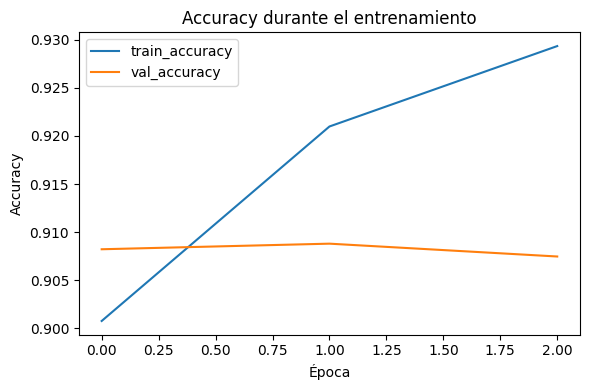

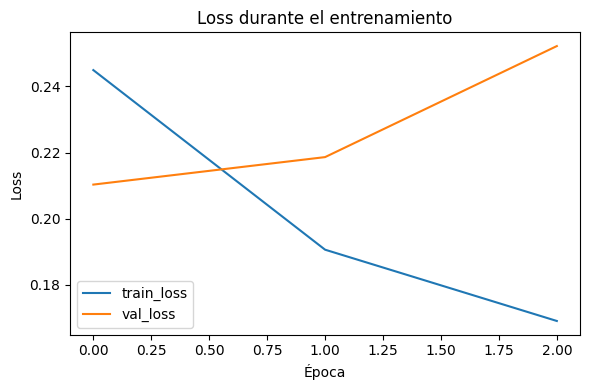

In [21]:
plot_history(history)

## Evaluamos en test

In [22]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

1142/1142 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9096 - loss: 0.2508
Test loss: 0.25079861283302307
Test accuracy: 0.9095536470413208


## Probamos algunas predicciones nuevas

In [23]:
sample_reviews = [
    "This baby product is amazing. It is easy to use and very helpful.",
    "I am very disappointed. The quality is poor and it broke quickly.",
    "The product is okay, but I expected something better for the price."
]

sample_seq = tokenizer.texts_to_sequences(sample_reviews)
sample_pad = keras.preprocessing.sequence.pad_sequences(
    sample_seq, maxlen=MAX_LEN, padding="post", truncating="post"
)

pred_probs = model.predict(sample_pad)
pred_labels = (pred_probs > 0.5).astype(int).flatten()

for review, prob, label in zip(sample_reviews, pred_probs.flatten(), pred_labels):
    print("Review:", review)
    print("Probabilidad positiva:", float(prob))
    print("Predicción:", "positiva" if label == 1 else "negativa")
    print("-" * 80)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
Review: This baby product is amazing. It is easy to use and very helpful.
Probabilidad positiva: 0.9999735355377197
Predicción: positiva
--------------------------------------------------------------------------------
Review: I am very disappointed. The quality is poor and it broke quickly.
Probabilidad positiva: 0.006507690995931625
Predicción: negativa
--------------------------------------------------------------------------------
Review: The product is okay, but I expected something better for the price.
Probabilidad positiva: 0.7364805936813354
Predicción: positiva
--------------------------------------------------------------------------------


## Comparación conceptual con la sesión 4

En la sesión 4 usamos un enfoque recurrente, por ejemplo:

**Embedding + LSTM + Dense**

Aquí usamos:

**Token + Position Embedding + Transformer Encoder + Dense**

La diferencia conceptual central es:

- en LSTM el contexto se modela de manera recurrente,
- en el transformer encoder el contexto se modela mediante **self-attention**.

## Ideas importantes para recordar

- Este notebook no usa un transformer preentrenado.
- Aquí construimos una versión simple de un **encoder transformer**.
- La atención permite relacionar distintas posiciones de la secuencia.
- Los embeddings de posición son importantes porque el orden sigue importando.
- Esta arquitectura puede usarse para clasificación de texto.

## Cierre

En este notebook vimos cómo construir un transformer encoder simple en Keras/TensorFlow para análisis de sentimiento.

El flujo general fue:

1. tokenizar texto,
2. agregar embeddings de token y posición,
3. aplicar un bloque encoder transformer,
4. resumir la secuencia,
5. clasificar la reseña.

Con esto ya tenemos una visión más concreta de cómo se arma internamente un modelo de este tipo.